Checking our numerical routines to ensure that the 2D screened Coulomb
$$ \tilde{\cal K}_{q_s}(q) = \frac{2 \pi }{q^2 + q_s^2} $$
in real space is understood as 
$$ {\cal K}_{q_s}(r) = K_0(q_s r).$$

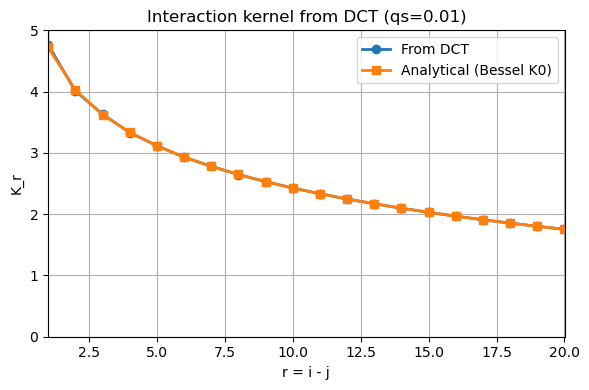

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import math, os, time, copy
import torch.fft as tfft
import pandas as pd
import torch_dct as dct
from numpy import size
from mpl_toolkits.axes_grid1 import make_axes_locatable
from ewaldnn2d import *

torch.random.manual_seed(1234) # for reproducibility

# Global settings
dtype = torch.float64
device = "cpu"

# grid and basis settings
N_x = 512 # number of grid points in x direction
N_y = N_x # number of grid points in y direction
m_x = torch.arange(0, N_x, dtype=dtype, device=device)             # (N_x,)
m_y = torch.arange(0, N_y, dtype=dtype, device=device)             # (N_y,)
abs_val = torch.sqrt(m_x[:, None]**2 + m_y[None, :]**2)  # (M_x, M_y)
x = torch.linspace(0, 1, N_x, dtype=dtype, device=device)            # (N_x,)
y = torch.linspace(0, 1, N_y, dtype=dtype, device=device)            # (N_y,)

# interaction kernel parameters
qs = 0.01 # screening momentum
amp = 1.0 # amplitude of interaction kernel
    
# --- visualize the interaction kernel ---
m_vals = torch.arange(0, N_x, device=device, dtype=dtype)
n_vals = torch.arange(0, N_y, device=device, dtype=dtype)
q_x = torch.pi * m_vals.view(-1, 1) / (N_x - 1)
q_y = torch.pi * n_vals.view(1, -1) / (N_y - 1)
q_vals = torch.sqrt(q_x**2 + q_y**2)  # (N_x, N_y)
lam_K =  amp * Lam_K_Coulomb(q_vals, qs=qs)
K = kernel_from_eigenvals_dct(lam_K)

x_vals = torch.arange(0, N_x, device=device, dtype=dtype).view(-1, 1)   # (N_x, 1)
y_vals = torch.arange(0, N_y, device=device, dtype=dtype).view(1, -1)   # (1, N_y)
r_vals = torch.sqrt(x_vals**2 + y_vals**2)  # (N_x, N_y)

# K_log_r = - torch.log(r_vals)  # K_r = -log(r) 
# K_log_r[0, 0] = 0.0  # define K_0 = 0
# Lam_K_log_r = kernel_eigenvals_dct(K_log_r) 
# Lam_K_log_r[0, 0] = 0.0 # avoid division by zero
# K_log_r = amp * kernel_from_eigenvals_dct(Lam_K_log_r)


K_analytical_q = torch.special.modified_bessel_k0(torch.clamp(qs * x_vals, min=torch.finfo(dtype).eps))

plt.figure(figsize=(6,4))
plt.plot(x_vals, K[:, 0], 'o-', linewidth=2, label="From DCT")
# plt.plot(x_vals, K_log_r[:, 0], 'x-', linewidth=2, label="True")
plt.plot(x_vals, K_analytical_q[:, 0], 's-', linewidth=2, label="Analytical (Bessel K0)")
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel("r = i - j")
plt.ylabel("K_r")
plt.title(f"Interaction kernel from DCT (qs={qs})")
plt.grid(True)
plt.ylim([0, 5])
plt.xlim([1, 20])
plt.tight_layout()
plt.legend()
plt.show()


#Small deviation can be induced by removing the homogeneous mode with q = 0.0 (not necessesary but we do it here)

